In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import timm
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import Callable
from PIL import Image

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Path diretory of dataset
TRAIN_DIR = '/kaggle/input/brain-tumor-mri-dataset/Training'
TRAIN_DIR

'/kaggle/input/brain-tumor-mri-dataset/Training'

In [5]:
# Path diretory of testing data
TEST_DIR = '/kaggle/input/brain-tumor-mri-dataset/Testing'
TEST_DIR

'/kaggle/input/brain-tumor-mri-dataset/Testing'

In [6]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
# 4 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor, No Tumor

CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
CLASS_NAMES

['glioma', 'meningioma', 'notumor', 'pituitary']

In [8]:
# ResNet50
MODEL1_DIR = '/kaggle/input/datasets/hophamsailam/resnet50-kaggle-train-test-validation'
# VGG19
MODEL2_DIR = '/kaggle/input/datasets/hophamsailam/vgg19-kaggle-train-test-validation'

In [9]:
# Model name
MODEL1_NAME = 'ResNet50'
MODEL2_NAME = 'VGG19'

MODEL_ENSEMBLE_NAME = f'tta-{MODEL1_NAME}_{MODEL2_NAME}'

In [10]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 4
DROPOUT_RATE = 0.3
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

In [11]:
def get_data_loaders(train_dir: str = TRAIN_DIR, test_dir: str = TEST_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders from train and test directories.

    Args:
        train_dir (str): Path to the training dataset directory.
        test_dir (str): Path to the test/validation dataset directory.
        batch_size (int): Batch size.

    Returns:
        tuple[DataLoader, DataLoader]: (train_loader, val_loader)
    """
    
    # Standard ImageNet normalization statistics (Required for weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    train_dataset = ImageFolder(root=train_dir, transform=train_transform)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    val_dataset = ImageFolder(root=test_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [12]:
class ResNet50(nn.Module):
    """
    ResNet50-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: ResNet50 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained ResNet50
        weights = models.ResNet50_Weights.IMAGENET1K_V1
        original_model = models.resnet50(weights=weights)

        # Feature Extractor
        # ResNet50 structure: [conv1, bn1, ..., layer1, layer2, layer3, layer4, avgpool, fc]
        # We remove the last 2 layers ('avgpool' and 'fc') to keep only the convolutional part.
        self.features = nn.Sequential(*list(original_model.children())[:-2])

        # 3. Freeze parameters
        for param in self.features.parameters():
            param.requires_grad = False

        # 4. Define Custom Classifier Head
        # ResNet50's final conv block (layer4) outputs 2048 channels.
        self.in_features = 2048 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 2048, H, W) -> (Batch, 2048, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 2048, 1, 1) -> (Batch, 2048)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [13]:
def build_resnet50(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> ResNet50:
    """
    Factory function to instantiate the customized ResNet50 model for Transfer Learning.

    This function initializes a `ResNet50` which includes:
    1. A frozen ResNet50 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        ResNet50: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = ResNet50(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [14]:
class VGG19(nn.Module):
    """
    VGG19-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: VGG19 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained VGG19
        weights = models.VGG19_Weights.IMAGENET1K_V1
        backbone = models.vgg19(weights=weights)

        # VGG19 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 512, H, W) -> (Batch, 512, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 512, 1, 1) -> (Batch, 512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes) # VGG19 features output exactly 512 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [15]:
def build_vgg19(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> VGG19:
    """
    Factory function to instantiate the customized VGG19 model for Transfer Learning.

    This function initializes a `VGG19` which includes:
    1. A frozen VGG19 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        VGG19Classifier: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = VGG19(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [16]:
class UnNormalize(nn.Module):
    """
    A module to reverse standard image normalization (e.g., ImageNet stats).
    Useful for restoring tensors to [0, 1] range for visualization or TTA.
    """

    def __init__(self, mean: list = [0.485, 0.456, 0.406], std: list = [0.229, 0.224, 0.225]):
        """
        Args:
            mean (list): The mean values (e.g., [0.485, 0.456, 0.406]).
            std (list): The std values (e.g., [0.229, 0.224, 0.225]).
        """
        super().__init__()
        # View (1, 3, 1, 1) to broadcast across batch and spatial dimensions
        self.mean = torch.tensor(mean).view(1, 3, 1, 1)
        self.std = torch.tensor(std).view(1, 3, 1, 1)

    def forward(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Args:
            tensor (torch.Tensor): Input normalized tensor (B, C, H, W).
        Returns:
            torch.Tensor: Un-normalized tensor.
        """
        return tensor * self.std.to(tensor.device) + self.mean.to(tensor.device)

In [17]:
def tta_augmentation():
    """
    Transform for test time augmentation.
    """
    return v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.1, contrast=(0.9, 1.1)) 
    ])

In [18]:
def get_model_probabilities(model_builder: Callable[..., nn.Module], checkpoint_path: str, val_loader: DataLoader, num_classes: int = NUM_CLASSES, tta_rounds= 5) -> tuple[np.ndarray, np.ndarray]:
    """
    Loads a pretrained model checkpoint and computes class probabilities for the validation set.
    This function performs the inference phase:
    1. Rebuilds the model architecture.
    2. Loads the saved weights (.pth).
    3. Runs the forward pass to get logits.
    4. Applies Softmax to convert logits into probabilities.
    Args:
        model_builder (nn.Module): The class constructor (e.g., VGG19 or MobileNet).
        checkpoint_path (str): Full path to the model weight file (.pth).
        val_loader (DataLoader): DataLoader containing validation data.
        num_classes (int, optional): Number of target classes. Defaults to 3.
    Returns:
        tuple[np.ndarray, np.ndarray]:
            - probs: Array of shape (N_samples, N_classes) containing predicted probabilities.
            - true_labels: Array of shape (N_samples,) containing ground truth labels.
    """
    # Init Model & Load Weights
    model = model_builder(num_classes=num_classes).to(device)
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
        
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    
    all_probs = []
    all_labels = []
    # Unormalize 
    unorm = UnNormalize(mean=NORM_MEAN, std=NORM_STD)

    # Test time augmentation
    tta_transform = tta_augmentation()

    # Normalize again
    norm = v2.Normalize(mean=NORM_MEAN, std=NORM_STD)

    # Inference Loop
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Inferencing {os.path.basename(checkpoint_path)}", leave=False):
            inputs = inputs.to(device)
            
            batch_probs_list = []
            # Forward (Get Logits)
            logits = model(inputs)
            batch_probs_list.append(torch.softmax(logits, dim=1))
            
            for _ in range(tta_rounds):
                # Denormalize
                inputs_denorm = unorm(inputs)
                # Get tta transform
                inputs_aug = tta_transform(inputs_denorm) 
                # Normalize again
                inputs_final = norm(inputs_aug)

                # Predict augmentation images.
                aug_logits = model(inputs_final)
                batch_probs_list.append(torch.softmax(aug_logits, dim=1))
            
            # Mean
            mean_probs = torch.stack(batch_probs_list).mean(dim=0)
            
            all_probs.extend(mean_probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return np.array(all_probs), np.array(all_labels)

In [19]:
MODEL1_WEIGHTS = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}.pth')
MODEL2_WEIGHTS = os.path.join(MODEL2_DIR, F'{MODEL2_NAME}.pth')

In [20]:
def generate_ensemble_soft_labels(train_dir: str = TRAIN_DIR, save_dir: str = SAVE_DIR, model1_path: str = MODEL1_WEIGHTS, model2_path: str = MODEL2_WEIGHTS, batch_size: int = BATCH_SIZE, norm_mean: list[float] = NORM_MEAN, norm_std: list[float] = NORM_STD, tta_rounds: int = 5) -> None:
    """
    Extracts and saves soft labels from an ensemble of two teacher models.
    
    This function sets up a non-shuffled DataLoader for the training dataset, 
    runs inference using Test-Time Augmentation (TTA) on two teacher models, 
    averages their output probabilities (soft voting), and saves the resulting 
    soft labels, hard labels, and image paths to disk as NumPy arrays.

    Args:
        train_dir (str, optional): Path to the training dataset directory. Defaults to TRAIN_DIR.
        save_dir (str, optional): Directory where the output .npy files will be saved. Defaults to SAVE_DIR.
        model1_path (str, optional): File path to the first model's weights (.pth). Defaults to MODEL1_WEIGHTS.
        model2_path (str, optional): File path to the second model's weights (.pth). Defaults to MODEL2_WEIGHTS.
        batch_size (int, optional): Number of images per batch. Defaults to BATCH_SIZE.
        norm_mean (list[float], optional): Mean values for image normalization. Defaults to NORM_MEAN.
        norm_std (list[float], optional): Standard deviation values for image normalization. Defaults to NORM_STD.
        tta_rounds (int, optional): Number of TTA rounds for inference. Defaults to 5.
        
    Returns:
        None: The function saves artifacts directly to the specified save_dir.
    """
    # 1. Define transformation pipeline (without random augmentations)
    extraction_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # 2. Configure Dataset and DataLoader (Shuffle MUST be False)
    num_workers = min(4, os.cpu_count())
    extraction_dataset = ImageFolder(
        root=train_dir,
        transform=extraction_transform,
    )

    extraction_loader = DataLoader(
        dataset=extraction_dataset,
        batch_size=batch_size,
        shuffle=False, # Strictly False to maintain image order
        num_workers=num_workers,
        pin_memory=True,
    )

    # 3. Extract image paths to map with generated labels later
    image_paths = [img_path for img_path, _ in extraction_dataset.samples]
    print(f'Dataset loaded. Total samples to extract: {len(image_paths)}')

    # 4. Generate probabilities from Teacher 1 (ResNet50)
    print(f'Extracting probabilities from Model 1 ({MODEL1_NAME})...')
    probs_1, hard_labels = get_model_probabilities(
        model_builder=build_resnet50,
        checkpoint_path=model1_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 5. Generate probabilities from Teacher 2 (VGG19)
    print(f'Extracting probabilities from Model 2 ({MODEL2_NAME})...')
    probs_2, _ = get_model_probabilities(
        model_builder=build_vgg19,
        checkpoint_path=model2_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 6. Ensemble (Soft Voting via simple averaging)
    soft_labels = (probs_1 + probs_2) / 2.0

    # 7. Save artifacts to disk
    np.save(os.path.join(save_dir, 'train_soft_labels.npy'), soft_labels)
    np.save(os.path.join(save_dir, 'train_hard_labels.npy'), hard_labels)
    np.save(os.path.join(save_dir, 'train_image_paths.npy'), image_paths)
    print(f'Extraction complete! Artifacts saved to: {save_dir}')

In [21]:
class DistillationDataset(Dataset):
    """
    Custom PyTorch Dataset for Offline Knowledge Distillation.
    
    This dataset loads images from file paths and pairs them with their 
    corresponding ground truth labels (hard labels) and teacher-generated 
    probabilities (soft labels).
    """
    def __init__(self, image_paths_file: str, hard_labels_file: str, soft_labels_file: str, transform: v2.Compose | None = None) -> None:
        """
        Args:
            image_paths_file (str): Path to the .npy file containing image paths.
            hard_labels_file (str): Path to the .npy file containing ground truth labels.
            soft_labels_file (str): Path to the .npy file containing teacher probabilities.
            transform (v2.Compose, optional): Transformations to apply to the images.
        """
        super().__init__()
        
        # Load data from saved .npy files
        self.image_paths = np.load(image_paths_file)
        self.hard_labels = np.load(hard_labels_file)
        self.soft_labels = np.load(soft_labels_file)
        self.transform = transform

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Retrieves a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve.
            
        Returns:
            tuple: (image_tensor, hard_label_tensor, soft_label_tensor)
        """
        # 1. Load image and convert to RGB (to ensure 3 channels)
        img_path = str(self.image_paths[idx])
        image = Image.open(img_path).convert('RGB')

        # 2. Apply data augmentations/transformations
        if self.transform:
            image = self.transform(image)

        # 3. Convert labels to Pytorch tensors
        # Hard label must be long (for Focal Loss), Soft label must be float (for KLDiv)
        hard_label = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        soft_label = torch.tensor(self.soft_labels[idx], dtype=torch.float32)

        return image, hard_label, soft_label

In [22]:
def get_distillation_loader(save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, norm_mean: list[float] = NORM_MEAN, norm_std: list[float] = NORM_STD) -> DataLoader:
    """
    Creates and returns a DataLoader for the DistillationDataset.
    
    Unlike the extraction step, this DataLoader APPLIES data augmentation 
    and ENABLES shuffling to properly train the Student model.
    """
    # 1. Define Training Transform Pipeline with Augmentations
    train_transform = v2.Compose([
        v2.Resize(size=256),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # 2. Define paths to the extracted .npy files
    image_paths_file = os.path.join(save_dir, 'train_image_paths.npy')
    hard_labels_file = os.path.join(save_dir, 'train_hard_labels.npy')
    soft_labels_file = os.path.join(save_dir, 'train_soft_labels.npy')

    # 3. Instantiate the Custom Dataset
    distill_dataset = DistillationDataset(
        image_paths_file=image_paths_file,
        hard_labels_file=hard_labels_file,
        soft_labels_file=soft_labels_file,
        transform=train_transform,
    )

    # 4. Create and return the DataLoader
    num_workers = min(4, os.cpu_count())
    distill_loader = DataLoader(
        dataset=distill_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f'Distillation DataLoader ready! Total samples: {len(distill_dataset)}, Total batches: {len(distill_loader)}')
    return distill_loader

In [23]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [24]:
def compute_distillation_loss(student_logits: torch.Tensor, soft_labels: torch.Tensor, hard_labels: torch.Tensor, focal_loss_fn: nn.Module, T: float = 3.0, alpha_distill: float = 0.5) -> torch.Tensor:
    """
    Computes the total offline knowledge distillation loss.
    
    This function combines two objective functions:
    1. Soft Target Loss (KL Divergence): Measures the divergence between the 
       student's softened predictions and the teacher's softened probabilities.
    2. Hard Target Loss (Focal Loss): Measures the error between the student's 
       raw predictions and the actual ground truth labels, focusing on hard examples.

    Args:
        student_logits (torch.Tensor): Raw, unnormalized logits output by the student model.
            Shape: (Batch_Size, Num_Classes).
        soft_labels (torch.Tensor): Probabilities generated by the teacher model (at T=1).
            Shape: (Batch_Size, Num_Classes).
        hard_labels (torch.Tensor): Ground truth class indices.
            Shape: (Batch_Size,).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module for hard targets.
        T (float, optional): Temperature scaling factor to soften probability distributions. 
            Higher values reveal more "dark knowledge". Defaults to 3.0.
        alpha_distill (float, optional): Weighting factor for the distillation loss. 
            (1 - alpha) will be applied to the hard loss. Defaults to 0.5.

    Returns:
        torch.Tensor: The computed scalar loss value for the batch.
    """
    # The teacher's soft_labels were saved as probabilities at T=1.
    # To simulate temperature scaling T, we take the T-th root (power of 1/T) 
    # and re-normalize so that the probabilities sum to 1 across the classes.
    teacher_probs_T = torch.pow(soft_labels, 1.0 / T)
    teacher_probs_T = teacher_probs_T / torch.sum(teacher_probs_T, dim=1, keepdim=True)

    # PyTorch's KLDivLoss expects the input (student) to be in log-space.
    # We apply the temperature T to the student's logits and use log_softmax.
    student_log_probs_T = F.log_softmax(student_logits / T, dim=1)

    # Compute the KL Divergence. reduction='batchmean' is mathematically correct.
    # We MUST multiply by T^2 to scale the gradients back to the same magnitude 
    # as the hard loss gradients, compensating for the 1/T scaling in logits.
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        student_log_probs_T,
        teacher_probs_T,
    ) * (T * T)

    # Compute the standard focal loss using the raw student logits (T=1)
    # and the true categorical labels.
    hard_loss = focal_loss_fn(logits=student_logits, targets=hard_labels)

    # Combine both losses using the alpha hyperparameter.
    total_loss = alpha_distill * soft_loss + (1.0 - alpha_distill) * hard_loss
    return total_loss

In [25]:
def build_student_model(num_classes: int = 4) -> nn.Module:
    """Builds ShuffleNet V2 1.0x via torchvision to avoid timm alias drift."""
    print("Initializing shufflenet_v2_x1_0 student model (Fully Unfrozen)...")
    
    weights = models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    model = models.shufflenet_v2_x1_0(weights=weights)
    
    # Surgically replace the native Linear head
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features=in_features, out_features=num_classes)
    
    for param in model.parameters():
        param.requires_grad = True
        
    return model

In [26]:
def train_epoch(model: nn.Module, data_loader: DataLoader, optimizer: torch.optim.Optimizer, focal_loss_fn: nn.Module, T: float = 3.0, alpha: float = 0.5, epoch_idx: int = 1, total_epochs: int = 100) -> tuple[float, float]:
    """
    Trains the student model for a single epoch using Offline Knowledge Distillation.
    
    This function iterates over the training dataloader, computes the combined 
    distillation loss (KL Divergence + Focal Loss), and updates the model weights.

    Args:
        model (nn.Module): The student neural network model.
        dataloader (DataLoader): DataLoader yielding (inputs, hard_labels, soft_labels).
        optimizer (Optimizer): The optimization algorithm (e.g., Adam).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        T (float, optional): Temperature for distillation. Defaults to 3.0.
        alpha (float, optional): Weight for the soft loss. Defaults to 0.5.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.

    Returns:
        tuple[float, float]: A tuple containing the training loss and accuracy percentage.
    """
    model.train()
    
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Train]', leave=False)

    for inputs, hard_labels, soft_labels in progress_bar:
        inputs, hard_labels, soft_labels = inputs.to(device=device), hard_labels.to(device=device), soft_labels.to(device=device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: get the student's raw logits
        student_logits = model(inputs)

        # Compute the combined offline distillation loss
        loss = compute_distillation_loss(
            student_logits=student_logits,
            soft_labels=soft_labels,
            hard_labels=hard_labels,
            focal_loss_fn=focal_loss_fn,
            T=T,
            alpha_distill=alpha,
        )

        # Backward pass: compute gradients
        loss.backward()

        # Optimizer step: update model weights
        optimizer.step()

        # Accumulate loss, accuracy and update progress bar
        train_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(student_logits, dim=1)
        correct_train += torch.sum(preds == hard_labels).item()
        total_train += hard_labels.size(0)

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average training loss, accuracy across all batches
    epoch_loss = train_loss / total_train
    epoch_acc = float(correct_train) / total_train

    return epoch_loss, epoch_acc

In [27]:
def test_epoch(model: nn.Module, data_loader: DataLoader, focal_loss_fn: nn.Module, epoch_idx: int = 1, total_epochs: int = 100, return_preds: bool = False) -> tuple[float, float] | tuple[float, float, list[int], list[int]]:
    """
    Evaluates the student model on the validation or test dataset for a single epoch.
    
    This function computes the standard loss (Hard Loss / Focal Loss) and accuracy 
    without tracking gradients to save memory and computation. It can optionally 
    return the raw predictions and true labels for further metric analysis.

    Args:
        model (nn.Module): The student neural network model.
        data_loader (DataLoader): DataLoader yielding (inputs, labels) only.
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.
        return_preds (bool, optional): If True, the function also returns the lists of 
            true labels and predicted labels. Defaults to False.

    Returns:
        If return_preds is False:
            tuple[float, float]: A tuple containing (average_loss, accuracy_ratio).
        If return_preds is True:
            tuple[float, float, list[int], list[int]]: A tuple containing 
            (average_loss, accuracy_ratio, y_true_list, y_pred_list).
    """
    model.eval()

    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    y_true_list = []
    y_pred_list = []

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Val]', leave=False)

    # Disable gradient calculation for inference
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass: get the student's raw logits
            logits = model(inputs)

            # Compute the hard loss (Focal Loss) using ground truth labels
            loss = focal_loss_fn(logits=logits, targets=labels)
            running_loss += loss.item()

            # Calculate predictions by finding the index with the maximum logit
            preds = torch.argmax(logits, dim=1)

            # Count correct predictions and total samples
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average loss and accuracy percentage
    avg_loss = running_loss / len(data_loader)
    accuracy = float(correct_preds) / total_preds

    if return_preds:
        return avg_loss, accuracy, y_true_list, y_pred_list

    return avg_loss, accuracy

In [28]:
def train_student_distillation(train_loader: DataLoader, val_loader: DataLoader, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-3, T: float = 3.0, alpha_distill: float = 0.5) -> dict[str, list[float]]:
    """
    Trains a student model using Knowledge Distillation with Early Stopping and Learning Rate Reduction.

    This function orchestrates the training and validation loops, tracking losses and
    accuracies over epochs. It uses a combination of hard targets (via Focal Loss) and
    soft targets (via KL Divergence) to transfer knowledge from a teacher model. The
    best model weights are automatically saved based on validation accuracy.

    Args:
        train_loader (DataLoader): DataLoader for the training set, yielding (inputs, hard_labels, soft_labels).
        val_loader (DataLoader): DataLoader for the validation/test set, yielding (inputs, labels).
        save_dir (str, optional): Directory path to save the best model weights. Defaults to global SAVE_DIR.
        batch_size (int, optional): Number of samples per batch. Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. Defaults to 1e-3.
        T (float, optional): Temperature scaling factor for distillation to soften probabilities. Defaults to 3.0.
        alpha_distill (float, optional): Weighting factor for the soft distillation loss. Defaults to 0.5.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history metrics per epoch:
            - 'loss': List of training losses.
            - 'accuracy': List of training accuracies.
            - 'val_loss': List of validation losses.
            - 'val_accuracy': List of validation accuracies.
    """
    model = build_student_model().to(device=device)
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    early_stop_patience = 15
    early_stop_counter = 0
    checkpoint_path = os.path.join(save_dir, 'student_distilled.pth')

    for epoch in range(epochs):

        epoch_loss, epoch_acc = train_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            focal_loss_fn=criterion,
            T=T,
            alpha=alpha_distill,
            epoch_idx=epoch+1,
            total_epochs=epochs,
        )

        epoch_val_loss, epoch_val_acc = test_epoch(
            model=model,
            data_loader=val_loader,
            focal_loss_fn=criterion,
            epoch_idx=epoch+1,
            total_epochs=epochs,
            return_preds=False,
        )

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break

    model.load_state_dict(state_dict=best_model_weights)
    return history

In [29]:
def plot_training_history(history: dict[str, list[float]], save_path: str | None = None) -> None:
    """
    Plots the training and validation learning curves (Loss and Accuracy).

    Args:
        history (dict[str, list[float]]): The dictionary containing training metrics 
            ('loss', 'accuracy', 'val_loss', 'val_accuracy') returned by the training loop.
        save_path (str, optional): If provided, saves the plot to this file path. 
            Defaults to None (only displays the plot).
    """
    # Get the actual number of epochs (handles Early Stopping cases)
    epochs = range(1, len(history['loss']) + 1)
    
    # Set the figure size (1 wide figure divided into 2 subplots)
    plt.figure(figsize=(15, 5))
    
    # 1. LOSS SUBPLOT
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Add a subtle grid for better readability
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # 2. ACCURACY SUBPLOT
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, history['val_accuracy'], 'r--', label='Validation Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    
    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_path}")
        
    # Display the plot
    plt.show()

In [30]:
def test_student_distillation(train_loader: DataLoader, val_loader: DataLoader, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR) -> float:
    """
    Orchestrates the full training and evaluation pipeline for the distilled student model.

    This function performs an end-to-end workflow:
    1. Trains the student model using knowledge distillation.
    2. Plots the training and validation learning curves.
    3. Loads the best model weights saved during the training phase.
    4. Evaluates the best model on the validation/test dataset.
    5. Generates and prints a performance summary, classification report, and plots a confusion matrix.

    Args:
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation or test dataset.
        class_names (list[str], optional): List of class names for the classification report 
            and confusion matrix axes. Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory where the model checkpoints are saved and loaded from. 
            Defaults to global SAVE_DIR.

    Returns:
        float: The final accuracy score of the best model on the validation/test set.
    """
    # 1. Train the model
    history = train_student_distillation(
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=save_dir,
    )

    # 2. Plot Learning Curves
    plot_training_history(history=history)

    # 3. Load the best model weights
    checkpoint_path = os.path.join(save_dir, 'student_distilled.pth')
    model = build_student_model().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    
    # 4. Setup evaluation
    criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)

    # 5. Inference and collect predictions
    runs = 5
    run_accs = []
    run_losses = []

    for i in range(runs):
        loss, acc, y_true_list, y_pred_list = test_epoch(
            model=model,
            data_loader=val_loader,
            focal_loss_fn=criterion,
            epoch_idx=1,
            total_epochs=1,
            return_preds=True,
        )
        run_accs.append(acc)
        run_losses.append(loss)
        print(f'Run {i + 1}: Val accuracy = {acc*100:.2f}% | Loss = {loss:.4f}')

    loss = np.mean(run_losses)
    acc = np.mean(run_accs)

    # 6. Report Results
    results = [{
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Dataset loaded. Total samples to extract: 5712
Extracting probabilities from Model 1 (ResNet50)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


Extracting probabilities from Model 2 (VGG19)...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 174MB/s]


Extraction complete! Artifacts saved to: /kaggle/working/
Distillation DataLoader ready! Total samples: 5712, Total batches: 179
Initializing shufflenet_v2_x1_0 student model (Fully Unfrozen)...
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


...

Epoch 46/100 | loss: 0.0242 - accuracy: 0.9995 | val_loss: 0.0061 - val_accuracy: 0.9977
val_accuracy did not improve from 0.9977


Epoch 47/100 | loss: 0.0260 - accuracy: 0.9991 | val_loss: 0.0058 - val_accuracy: 0.9977
val_accuracy did not improve from 0.9977


Epoch 48/100 | loss: 0.0255 - accuracy: 0.9995 | val_loss: 0.0059 - val_accuracy: 0.9977
val_accuracy did not improve from 0.9977


Epoch 49/100 | loss: 0.0245 - accuracy: 0.9991 | val_loss: 0.0058 - val_accuracy: 0.9977
val_accuracy did not improve from 0.9977


Epoch 50/100 | loss: 0.0251 - accuracy: 0.9991 | val_loss: 0.0060 - val_accuracy: 0.9969
val_accuracy did not improve from 0.9977
early stopping, restoring model weights from the end of the best epoch


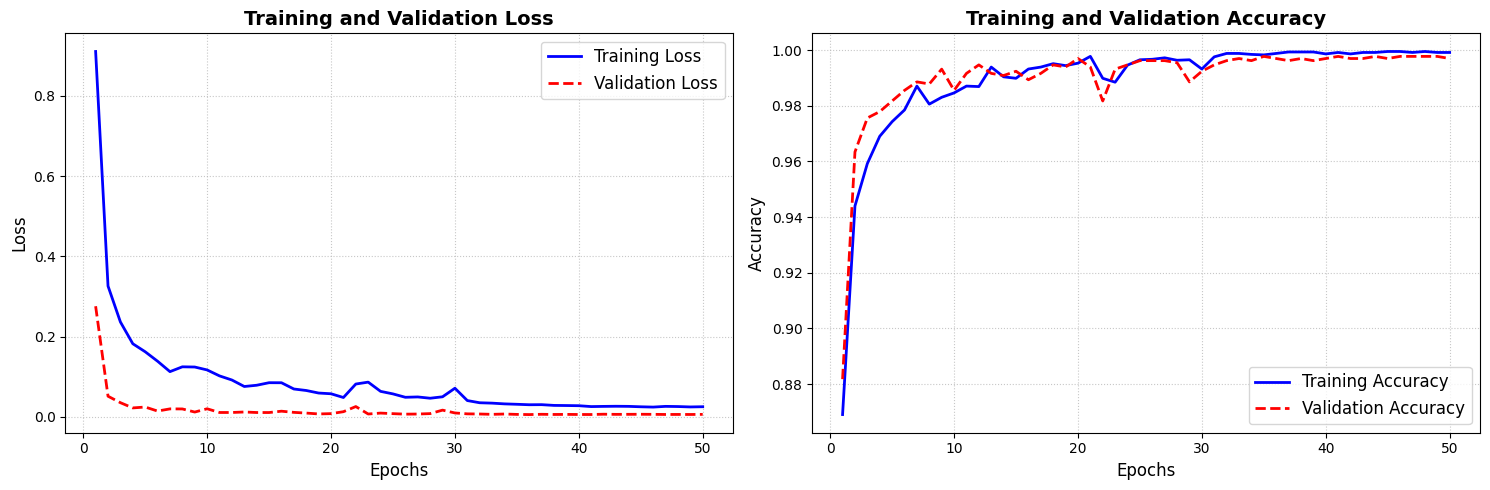

Initializing shufflenet_v2_x1_0 student model (Fully Unfrozen)...
Total params: 1,257,704
Trainable params: 1,257,704


Run 1: Val accuracy = 99.77% | Loss = 0.0059


Run 2: Val accuracy = 99.77% | Loss = 0.0059


Run 3: Val accuracy = 99.77% | Loss = 0.0059


Run 4: Val accuracy = 99.77% | Loss = 0.0059


Run 5: Val accuracy = 99.77% | Loss = 0.0059
      Loss  Accuracy
0  0.00595  0.997712
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      0.99      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



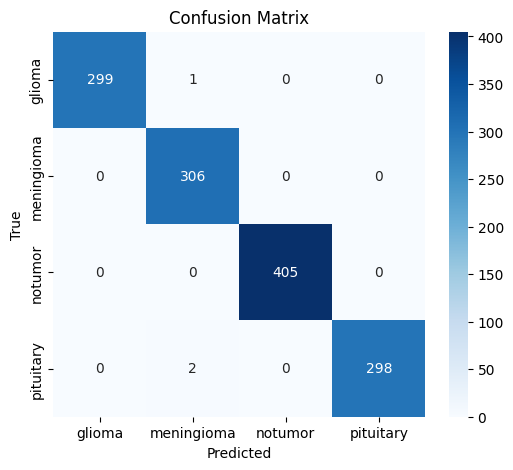

Accuracy: 99.77%


In [31]:
_, val_loader = get_data_loaders()

generate_ensemble_soft_labels()

train_loader_distill = get_distillation_loader()

final_accuracy = test_student_distillation(
    train_loader=train_loader_distill,
    val_loader=val_loader,
)

print(f'Accuracy: {final_accuracy * 100:.2f}%')